# Evolution of Female Representation in Cinema (1950-2026)

**Data Mining Project - University Seminar**

**Topic**: An analysis of gender representation trends, lead-role balance, top-billed screen presence, genre patterns, age distributions, and audience perception using IMDb metadata and Bechdel Test labels.

**Research focus**: This notebook uses IMDb `title.basics`, `title.principals`, `name.basics`, and `title.ratings`, plus an external Bechdel dataset. Because IMDb does not provide full screenplay or review text in these files, `ordering` in `title.principals` is used as a proxy for lead prominence and top-billed screen presence, while audience perception is measured with ratings rather than textual sentiment.

**Hypothesis**: Female representation has improved over time, but gaps persist in lead roles, top billing, age distribution, and genre-level representation quality.

In [17]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator

# Settings for high-quality visuals
plt.style.use('ggplot')
sns.set_palette('husl')
%matplotlib inline

# Analysis configuration
ANALYSIS_START_YEAR = 1950
ANALYSIS_END_YEAR = 2026
TOP_BILLED_CUTOFF = 10
MIN_VOTES_FOR_RATINGS = 1000
BOOTSTRAP_ITERATIONS = 2000

# Configuration
RAW_DIR = '../data/raw/'
EXT_DIR = '../data/external/'
PROC_DIR = '../data/processed/'
PROCESSED_MOVIES = os.path.join(PROC_DIR, 'filtered_movies.csv')
PROCESSED_CAST = os.path.join(PROC_DIR, 'filtered_cast.csv')

CACHE_REQUIRED_MOVIE_COLUMNS = {
    'tconst', 'primaryTitle', 'startYear', 'genres', 'averageRating', 'numVotes',
    'lead_category', 'lead_name', 'female_top10_share', 'binary', 'clean_test'
}
CACHE_REQUIRED_CAST_COLUMNS = {
    'tconst', 'ordering', 'nconst', 'primaryName', 'category', 'birthYear',
    'startYear', 'genres', 'age_at_release', 'decade'
}

os.makedirs(PROC_DIR, exist_ok=True)

percent_formatter = FuncFormatter(lambda value, _: f'{value:.0f}')
rating_formatter = FuncFormatter(lambda value, _: f'{value:.1f}')

def style_decade_axis(ax):
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

def style_percent_axis(ax, axis='y'):
    if axis == 'y':
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(percent_formatter)
    else:
        ax.set_xlim(0, 100)
        ax.xaxis.set_major_formatter(percent_formatter)

print(f'Environment ready for {ANALYSIS_START_YEAR}-{ANALYSIS_END_YEAR}.')

Environment ready for 1950-2026.


## 1. The "Great Filter": Building the Movie Universe
IMDb datasets are multi-gigabyte files, so the notebook processes them in chunks. We keep non-adult feature films released between 1950 and 2026 as the base population for all later analyses.

In [18]:
# 1. Load and Filter Movies (1950-2026)
relevant_ids = set()
CACHE_READY = False

if os.path.exists(PROCESSED_MOVIES) and os.path.exists(PROCESSED_CAST):
    cached_movies = pd.read_csv(PROCESSED_MOVIES, low_memory=False)
    cached_cast = pd.read_csv(PROCESSED_CAST, low_memory=False)

    if (
        CACHE_REQUIRED_MOVIE_COLUMNS.issubset(cached_movies.columns)
        and CACHE_REQUIRED_CAST_COLUMNS.issubset(cached_cast.columns)
    ):
        movies_final = cached_movies.copy()
        cast_df = cached_cast.copy()

        movies_final['startYear'] = pd.to_numeric(movies_final['startYear'], errors='coerce')
        cast_df['startYear'] = pd.to_numeric(cast_df['startYear'], errors='coerce')
        cast_df['ordering'] = pd.to_numeric(cast_df['ordering'], errors='coerce')
        cast_df['birthYear'] = pd.to_numeric(cast_df['birthYear'], errors='coerce')
        cast_df['age_at_release'] = pd.to_numeric(cast_df['age_at_release'], errors='coerce')

        movies_df = movies_final[['tconst', 'primaryTitle', 'startYear', 'genres']].drop_duplicates().copy()
        relevant_ids = set(movies_df['tconst'])
        CACHE_READY = True

        print('Processed files found. Loading cached movie and cast tables...')
        print(f'Cache loaded. {len(movies_df):,} movies available from processed files.')
        print(f"Observed year range: {int(movies_df['startYear'].min())}-{int(movies_df['startYear'].max())}")
    else:
        print('Processed files exist, but required columns are missing. Rebuilding from raw files...')

if not CACHE_READY:
    movie_meta = []

    print('Processing title.basics.tsv...')
    basics_chunks = pd.read_csv(
        os.path.join(RAW_DIR, 'title.basics.tsv'),
        sep='\t',
        chunksize=100000,
        low_memory=False,
        na_values='\\N'
    )

    for chunk in basics_chunks:
        chunk['startYear'] = pd.to_numeric(chunk['startYear'], errors='coerce')
        mask = (
            (chunk['titleType'] == 'movie')
            & (chunk['isAdult'] == 0)
            & (chunk['startYear'] >= ANALYSIS_START_YEAR)
            & (chunk['startYear'] <= ANALYSIS_END_YEAR)
        )

        subset = chunk.loc[mask].copy()
        movie_meta.append(subset)
        relevant_ids.update(subset['tconst'].tolist())

    movies_df = pd.concat(movie_meta, ignore_index=True)
    movies_df = movies_df.drop_duplicates(subset='tconst').reset_index(drop=True)

    print(f'Extraction complete. {len(movies_df):,} movies identified.')
    print(f"Observed year range: {int(movies_df['startYear'].min())}-{int(movies_df['startYear'].max())}")

Processed files found. Loading cached movie and cast tables...
Cache loaded. 551,594 movies available from processed files.
Observed year range: 1950-2026


## 2. Cast, Lead Roles, and Screen-Presence Proxies
IMDb does not provide direct screen-time measurements, so this notebook uses `title.principals.ordering` as a proxy for prominence. We keep actor and actress rows from the top 10 billed credits, estimate each film's lead role from the first billed performer, and combine this with birth year data to analyze age at release.

In [19]:
if CACHE_READY:
    cast_df = cast_df.copy()
    cast_df['decade'] = pd.to_numeric(
        cast_df['decade'],
        errors='coerce'
    ).fillna(
        cast_df['startYear'] // 10 * 10
    ).astype(int)

    lead_df = movies_final.dropna(subset=['lead_category']).loc[
        :, ['tconst', 'lead_category', 'lead_name', 'startYear']
    ].copy()
    lead_df['decade'] = (lead_df['startYear'] // 10 * 10).astype(int)

    screen_presence_df = movies_final.dropna(subset=['female_top10_share']).loc[
        :, ['tconst', 'female_top10_share']
    ].copy()

    if 'age_at_release' in cast_df.columns:
        age_plot_df = cast_df[
            cast_df['age_at_release'].between(5, 95)
        ].copy()
    else:
        age_plot_df = cast_df.copy()

    print('Processed files found. Skipping raw cast rebuild and reusing cached cast features.')
    print(f'Top-billed cast rows retained: {len(cast_df):,}')
    print(f"Lead-role proxy available for {lead_df['tconst'].nunique():,} films.")

else:
    print('Processing cast, lead proxies, and birth years...')

    names = pd.read_csv(
        os.path.join(RAW_DIR, 'name.basics.tsv'),
        sep='\t',
        usecols=['nconst', 'primaryName', 'birthYear'],
        na_values='\\N'
    )

    relevant_categories = {'actor', 'actress'}
    cast_list = []

    principals_chunks = pd.read_csv(
        os.path.join(RAW_DIR, 'title.principals.tsv'),
        sep='\t',
        chunksize=500000,
        na_values='\\N'
    )

    for chunk in principals_chunks:
        chunk['ordering'] = pd.to_numeric(chunk['ordering'], errors='coerce')

        mask = (
            chunk['tconst'].isin(relevant_ids)
            & chunk['category'].isin(relevant_categories)
            & (chunk['ordering'] <= TOP_BILLED_CUTOFF)
        )

        cast_list.append(
            chunk.loc[
                mask,
                ['tconst', 'ordering', 'nconst', 'category', 'characters']
            ].copy()
        )

    cast_df = pd.concat(cast_list, ignore_index=True)

    cast_df = cast_df.merge(
        names,
        on='nconst',
        how='left'
    )

    cast_df = cast_df.merge(
        movies_df[['tconst', 'startYear', 'genres']],
        on='tconst',
        how='left'
    )

    cast_df['birthYear'] = pd.to_numeric(
        cast_df['birthYear'],
        errors='coerce'
    )

    cast_df['age_at_release'] = cast_df['startYear'] - cast_df['birthYear']
    cast_df['decade'] = (cast_df['startYear'] // 10 * 10).astype(int)

    cast_prominence_df = cast_df.copy()

    lead_df = (
        cast_prominence_df
        .sort_values(['tconst', 'ordering'])
        .drop_duplicates(subset='tconst')
        [['tconst', 'ordering', 'nconst', 'primaryName', 'category', 'startYear']]
        .rename(columns={
            'category': 'lead_category',
            'primaryName': 'lead_name'
        })
        .copy()
    )

    lead_df['decade'] = (lead_df['startYear'] // 10 * 10).astype(int)

    screen_presence_df = (
        cast_prominence_df
        .groupby('tconst')['category']
        .apply(lambda values: (values == 'actress').mean() * 100)
        .reset_index(name='female_top10_share')
    )

    age_plot_df = cast_df[
        cast_df['age_at_release'].between(5, 95)
    ].copy()

    print(f'Top-billed cast rows retained: {len(cast_df):,}')
    print(f"Lead-role proxy available for {lead_df['tconst'].nunique():,} films.")
    print(f'Plausible age rows retained for age analysis: {len(age_plot_df):,}')

Processed files found. Skipping raw cast rebuild and reusing cached cast features.
Top-billed cast rows retained: 1,532,062
Lead-role proxy available for 323,168 films.


## 3. Merging Ratings and Bechdel Labels
We combine the filtered movie universe with IMDb ratings and an external Bechdel dataset. This gives us two different views of representation: audience reception through `averageRating` and `numVotes`, and female interaction quality through Bechdel pass or fail labels on a smaller matched subset.

In [20]:
if CACHE_READY:
    movies_final = movies_final.copy()
    movies_final['startYear'] = pd.to_numeric(movies_final['startYear'], errors='coerce')
    movies_final['averageRating'] = pd.to_numeric(movies_final['averageRating'], errors='coerce')
    movies_final['numVotes'] = pd.to_numeric(movies_final['numVotes'], errors='coerce')
    movies_final['female_top10_share'] = pd.to_numeric(
        movies_final['female_top10_share'], errors='coerce'
    )
    movies_final['lead_group'] = movies_final['lead_category'].map(
        {'actress': 'Female-led', 'actor': 'Male-led'}
    )
    movies_final['decade'] = (movies_final['startYear'] // 10 * 10).astype(int)

    ratings_sample = movies_final.dropna(subset=['averageRating', 'lead_group']).copy()
    ratings_sample = ratings_sample[ratings_sample['numVotes'] >= MIN_VOTES_FOR_RATINGS].copy()

    print('Processed files found. Skipping raw ratings and Bechdel merge.')
    print(f'Movies in analysis universe: {len(movies_final):,}')
    print(f"Films with lead-role proxy: {movies_final['lead_group'].notna().sum():,}")
    print(f"Films with Bechdel labels: {movies_final['binary'].notna().sum():,}")
    print(f'Films with ratings sample (>= {MIN_VOTES_FOR_RATINGS} votes): {len(ratings_sample):,}')
else:
    # Load Bechdel labels
    bechdel = pd.read_csv(os.path.join(EXT_DIR, 'movies.csv'), low_memory=False)
    bechdel['imdb'] = bechdel['imdb'].astype(str).apply(
        lambda value: value if value.startswith('tt') else 'tt' + value.zfill(7)
    )

    # Load IMDb ratings
    ratings = pd.read_csv(
        os.path.join(RAW_DIR, 'title.ratings.tsv'),
        sep='\t',
        usecols=['tconst', 'averageRating', 'numVotes']
    )

    # Merge to master movie frame
    movies_final = movies_df.merge(ratings, on='tconst', how='left')
    movies_final = movies_final.merge(
        bechdel[['imdb', 'binary', 'clean_test', 'budget_2013$', 'domgross_2013$']],
        left_on='tconst',
        right_on='imdb',
        how='left'
    )
    movies_final = movies_final.merge(
        lead_df[['tconst', 'lead_category', 'lead_name']],
        on='tconst',
        how='left'
    )
    movies_final = movies_final.merge(screen_presence_df, on='tconst', how='left')
    movies_final['lead_group'] = movies_final['lead_category'].map(
        {'actress': 'Female-led', 'actor': 'Male-led'}
    )
    movies_final['decade'] = (movies_final['startYear'] // 10 * 10).astype(int)

    ratings_sample = movies_final.dropna(subset=['averageRating', 'lead_group']).copy()
    ratings_sample = ratings_sample[ratings_sample['numVotes'] >= MIN_VOTES_FOR_RATINGS].copy()

    print(f'Movies in analysis universe: {len(movies_final):,}')
    print(f"Films with lead-role proxy: {movies_final['lead_group'].notna().sum():,}")
    print(f"Films with Bechdel labels: {movies_final['binary'].notna().sum():,}")
    print(f'Films with ratings sample (>= {MIN_VOTES_FOR_RATINGS} votes): {len(ratings_sample):,}')

Processed files found. Skipping raw ratings and Bechdel merge.
Movies in analysis universe: 551,594
Films with lead-role proxy: 323,168
Films with Bechdel labels: 1,784
Films with ratings sample (>= 1000 votes): 42,802


## 4. Visual Analysis
**A. Lead Roles and Top-Billed Screen Presence**
The first chart estimates the share of films with a female first-billed performer. The second chart uses the top 10 billed credits as a proxy for screen presence and asks how much of prominent cast space is occupied by women over time.

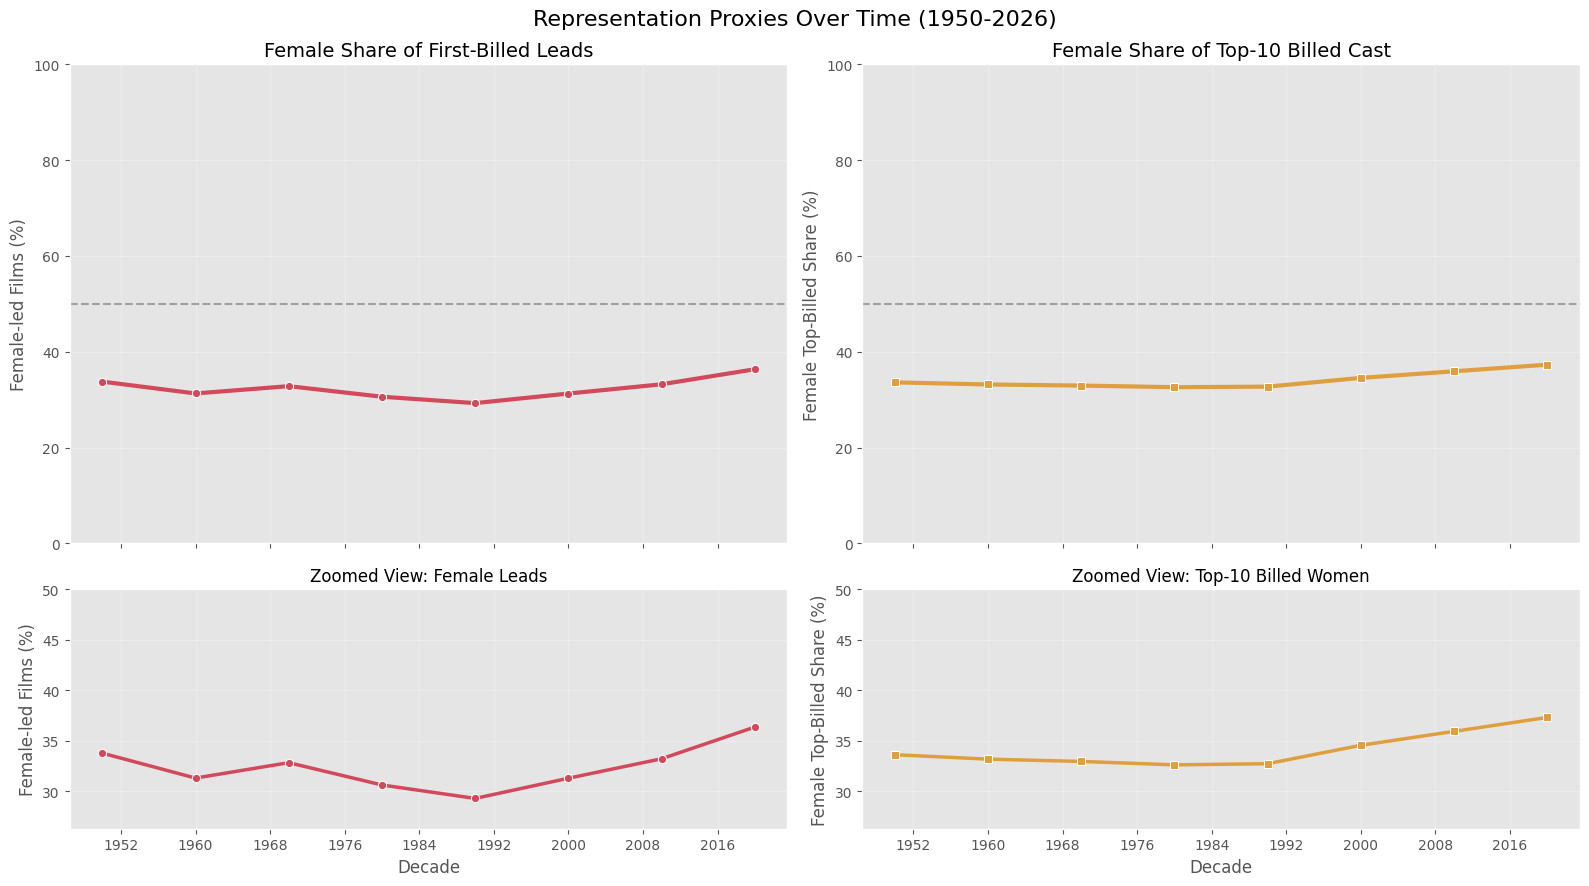

In [21]:
lead_share = (
    lead_df.groupby('decade')['lead_category']
    .apply(lambda values: (values == 'actress').mean() * 100)
    .reset_index(name='female_lead_share')
 )

top_billed_share = (
    cast_df.groupby('decade')['category']
    .apply(lambda values: (values == 'actress').mean() * 100)
    .reset_index(name='female_top10_share')
 )

zoom_floor = max(0, min(
    lead_share['female_lead_share'].min(),
    top_billed_share['female_top10_share'].min()
 ) - 3)
zoom_ceiling = 50

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 9),
    sharex='col',
    gridspec_kw={'height_ratios': [2.2, 1.1]}
 )

sns.lineplot(
    data=lead_share,
    x='decade',
    y='female_lead_share',
    marker='o',
    linewidth=3,
    color='#d1495b',
    ax=axes[0, 0]
 )
axes[0, 0].axhline(50, color='black', linestyle='--', alpha=0.3)
axes[0, 0].set_title('Female Share of First-Billed Leads', fontsize=14)
axes[0, 0].set_ylabel('Female-led Films (%)')
axes[0, 0].grid(True, alpha=0.3)
style_decade_axis(axes[0, 0])
style_percent_axis(axes[0, 0], axis='y')

sns.lineplot(
    data=top_billed_share,
    x='decade',
    y='female_top10_share',
    marker='s',
    linewidth=3,
    color='#e09f3e',
    ax=axes[0, 1]
 )
axes[0, 1].axhline(50, color='black', linestyle='--', alpha=0.3)
axes[0, 1].set_title('Female Share of Top-10 Billed Cast', fontsize=14)
axes[0, 1].set_ylabel('Female Top-Billed Share (%)')
axes[0, 1].grid(True, alpha=0.3)
style_decade_axis(axes[0, 1])
style_percent_axis(axes[0, 1], axis='y')

sns.lineplot(
    data=lead_share,
    x='decade',
    y='female_lead_share',
    marker='o',
    linewidth=2.5,
    color='#d1495b',
    ax=axes[1, 0]
 )
axes[1, 0].axhline(50, color='black', linestyle='--', alpha=0.3)
axes[1, 0].set_title('Zoomed View: Female Leads', fontsize=12)
axes[1, 0].set_xlabel('Decade')
axes[1, 0].set_ylabel('Female-led Films (%)')
axes[1, 0].set_ylim(zoom_floor, zoom_ceiling)
axes[1, 0].grid(True, alpha=0.3)
style_decade_axis(axes[1, 0])
axes[1, 0].yaxis.set_major_formatter(percent_formatter)

sns.lineplot(
    data=top_billed_share,
    x='decade',
    y='female_top10_share',
    marker='s',
    linewidth=2.5,
    color='#e09f3e',
    ax=axes[1, 1]
 )
axes[1, 1].axhline(50, color='black', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Zoomed View: Top-10 Billed Women', fontsize=12)
axes[1, 1].set_xlabel('Decade')
axes[1, 1].set_ylabel('Female Top-Billed Share (%)')
axes[1, 1].set_ylim(zoom_floor, zoom_ceiling)
axes[1, 1].grid(True, alpha=0.3)
style_decade_axis(axes[1, 1])
axes[1, 1].yaxis.set_major_formatter(percent_formatter)

for ax in axes[0, :]:
    ax.set_xlabel('')

plt.suptitle('Representation Proxies Over Time (1950-2026)', fontsize=16)
plt.tight_layout()
plt.show()

**A1. Stacked Lead Composition by Decade**
This chart shows the same lead-role idea in a simpler way: each decade is split into female-led and male-led shares, so it is easy to compare composition at a glance.

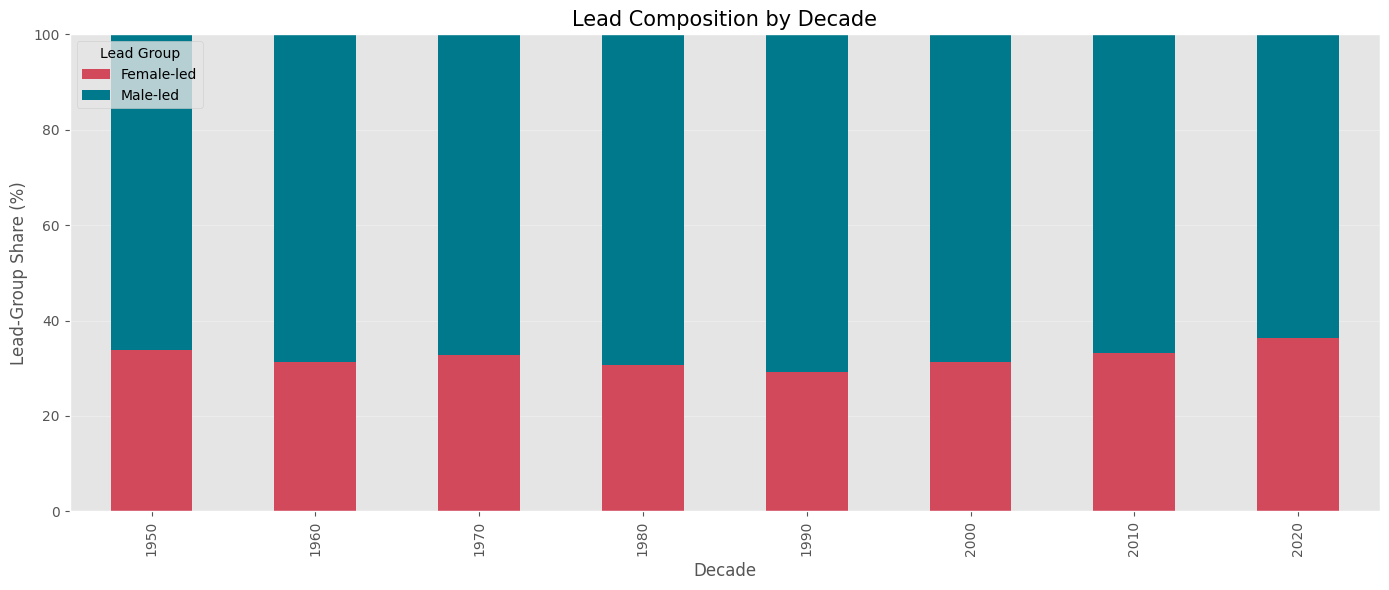

In [22]:
lead_composition = (
    lead_df.assign(lead_group=lead_df['lead_category'].map({'actress': 'Female-led', 'actor': 'Male-led'}))
    .groupby(['decade', 'lead_group'])['tconst']
    .nunique()
    .unstack(fill_value=0)
 )
lead_composition_pct = lead_composition.div(lead_composition.sum(axis=1), axis=0) * 100

lead_composition_pct[['Female-led', 'Male-led']].plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    color=['#d1495b', '#00798c']
 )
bar_ax = plt.gca()
bar_ax.set_title('Lead Composition by Decade', fontsize=15)
bar_ax.set_xlabel('Decade')
bar_ax.set_ylabel('Lead-Group Share (%)')
style_percent_axis(bar_ax, axis='y')
bar_ax.legend(title='Lead Group', loc='upper left')
bar_ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**A2. Genre-by-Decade Female Lead Share**
The overall trend can hide uneven progress across genres. This section tracks the percentage of female-led films within each genre by decade and highlights which genres saw the largest increase from the 1950s to the 2020s among genres with enough films in both periods. Cells marked `No data` mean that genre-decade slice did not have enough films to pass the minimum-count filter of 25 films.

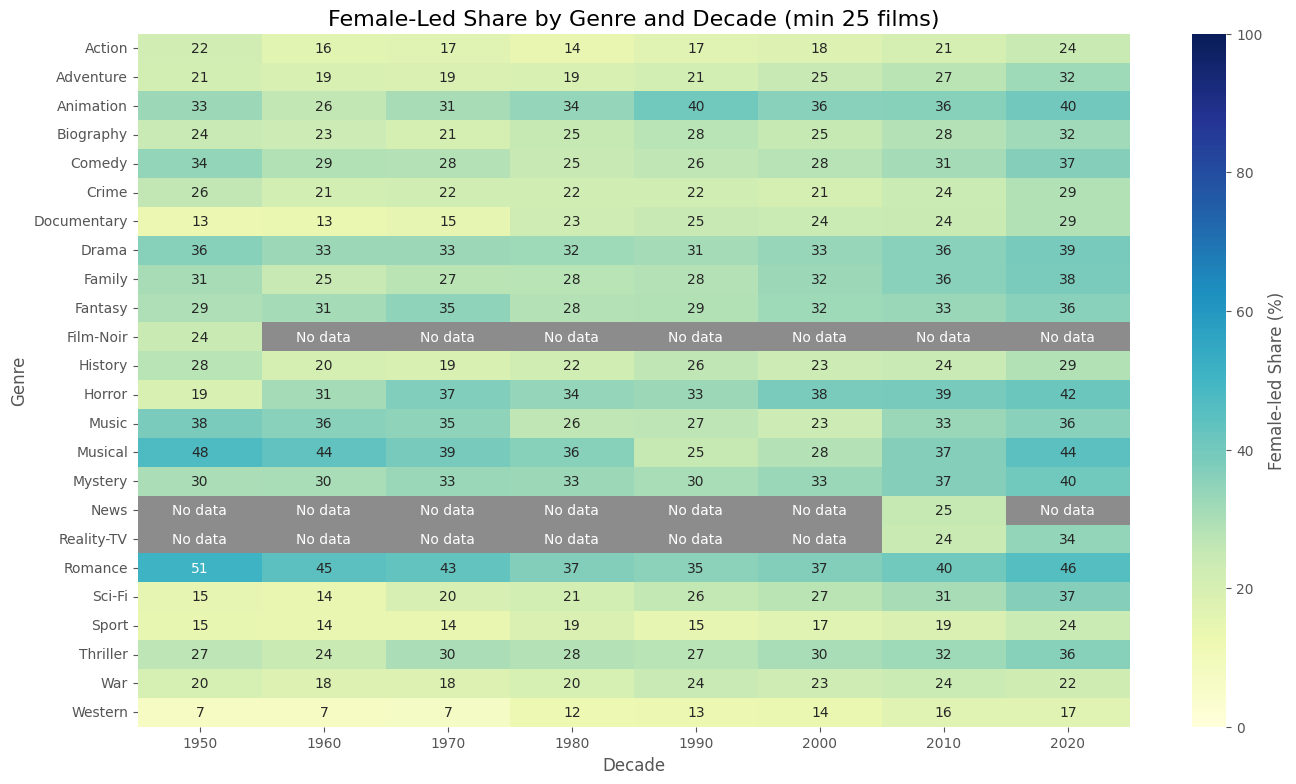

Largest increases from the 1950s to the 2020s for genres with at least 25 films in both decades:


decade,genres,1950,2020,change_points
0,Horror,19.15,41.57,22.42
1,Sci-Fi,15.04,36.64,21.60
2,Documentary,13.17,28.69,15.52
3,Adventure,21.24,32.37,11.13
4,Mystery,29.96,40.44,10.48
5,Western,7.41,17.08,9.68
6,Sport,14.62,23.80,9.19
7,Thriller,26.95,35.96,9.02
8,Family,30.65,38.30,7.65
9,Biography,24.30,31.69,7.39


In [23]:
genre_lead_df = movies_final.dropna(subset=['genres', 'lead_group']).copy()
genre_lead_df = genre_lead_df.assign(genres=genre_lead_df['genres'].str.split(',')).explode('genres')

genre_lead_summary = (
    genre_lead_df.groupby(['decade', 'genres'])
    .agg(
        films=('tconst', 'nunique'),
        female_lead_share=('lead_group', lambda values: (values == 'Female-led').mean() * 100)
    )
    .reset_index()
 )
genre_lead_summary = genre_lead_summary[genre_lead_summary['films'] >= 25].copy()

genre_lead_pivot = genre_lead_summary.pivot(
    index='genres',
    columns='decade',
    values='female_lead_share'
 )
genre_lead_display = genre_lead_pivot.fillna(-1)
genre_lead_labels = genre_lead_pivot.apply(
    lambda column: column.map(lambda value: 'No data' if pd.isna(value) else f'{value:.0f}')
 )

start_decade = int(genre_lead_summary['decade'].min())
end_decade = int(genre_lead_summary['decade'].max())
genre_improvement = genre_lead_pivot[[start_decade, end_decade]].dropna().copy()
genre_improvement['change_points'] = genre_improvement[end_decade] - genre_improvement[start_decade]
genre_improvement = genre_improvement.sort_values('change_points', ascending=False).reset_index()

lead_heatmap_cmap = sns.color_palette('YlGnBu', as_cmap=True)
lead_heatmap_cmap.set_under('#8c8c8c')

plt.figure(figsize=(16, 9))
lead_heatmap = sns.heatmap(
    genre_lead_display,
    annot=genre_lead_labels,
    cmap=lead_heatmap_cmap,
    fmt='',
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Female-led Share (%)'}
 )
lead_heatmap.collections[0].colorbar.ax.yaxis.set_major_formatter(percent_formatter)
plt.title('Female-Led Share by Genre and Decade (min 25 films)', fontsize=16)
plt.xlabel('Decade')
plt.ylabel('Genre')
plt.show()

print(
    f'Largest increases from the {start_decade}s to the {end_decade}s '
    f'for genres with at least 25 films in both decades:'
)

genre_improvement[['genres', start_decade, end_decade, 'change_points']].head(10).round(2)

**B. Age Distribution in Top-Billed Roles**
The age analysis focuses on actors and actresses who appear in the top 10 billed credits. This does not measure career length directly, but it does show whether women and men are being cast at different ages in prominent roles.

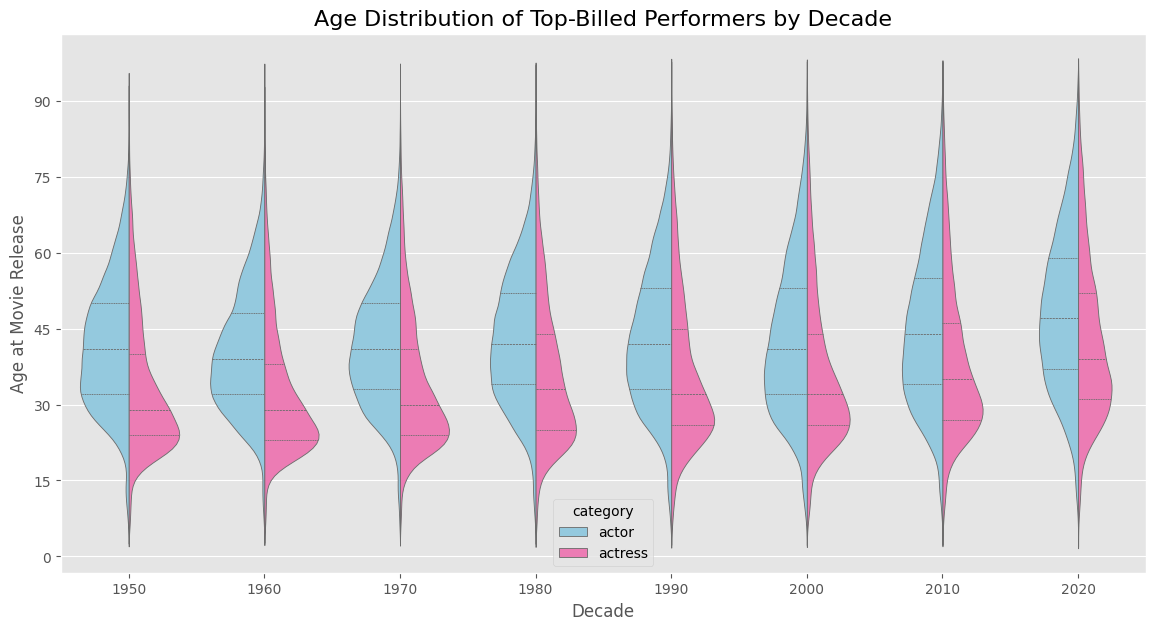

In [24]:
age_plot_df = cast_df.dropna(subset=['age_at_release']).copy()

plt.figure(figsize=(14, 7))
age_ax = sns.violinplot(
    data=age_plot_df,
    x='decade',
    y='age_at_release',
    hue='category',
    split=True,
    inner='quart',
    palette={'actor': 'skyblue', 'actress': 'hotpink'}
 )
age_ax.yaxis.set_major_locator(MaxNLocator(integer=True))
style_decade_axis(age_ax)
plt.title('Age Distribution of Top-Billed Performers by Decade', fontsize=16)
plt.ylabel('Age at Movie Release')
plt.xlabel('Decade')
plt.show()

**B1. Latest-Decade Age Histogram**
The violin plot shows the full shape over time, but this simpler histogram focuses only on the latest decade and makes the age gap easier to see directly.

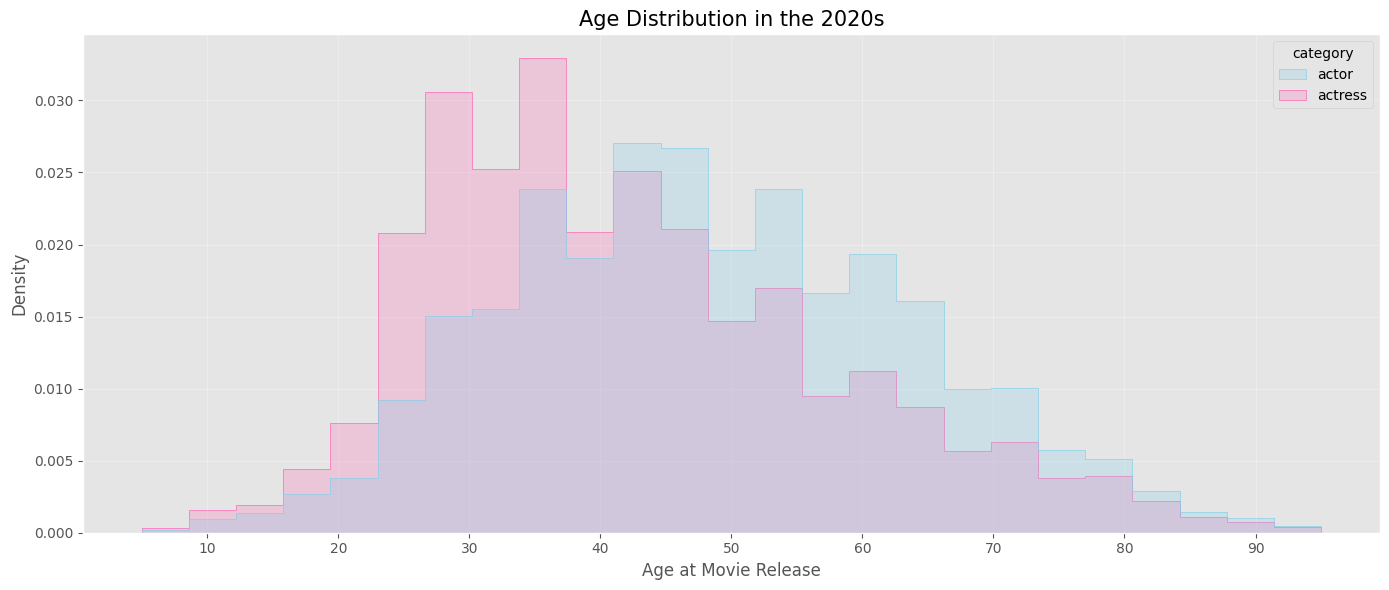

In [25]:
latest_age_decade = int(age_plot_df['decade'].max())
latest_age_hist = age_plot_df.loc[age_plot_df['decade'] == latest_age_decade].copy()

plt.figure(figsize=(14, 6))
hist_ax = sns.histplot(
    data=latest_age_hist,
    x='age_at_release',
    hue='category',
    bins=25,
    stat='density',
    common_norm=False,
    element='step',
    fill=True,
    alpha=0.25,
    palette={'actor': 'skyblue', 'actress': 'hotpink'}
 )
hist_ax.set_title(f'Age Distribution in the {latest_age_decade}s', fontsize=15)
hist_ax.set_xlabel('Age at Movie Release')
hist_ax.set_ylabel('Density')
hist_ax.xaxis.set_major_locator(MaxNLocator(integer=True))
hist_ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**C. Genre Patterns in Bechdel Pass Rates**
This heatmap uses the matched Bechdel subset only. To reduce noise, it keeps genre-decade combinations with at least 10 labeled films. Cells marked `No data` mean there were no matched labeled films in that genre-decade slice, or too few films to pass the minimum-count filter.

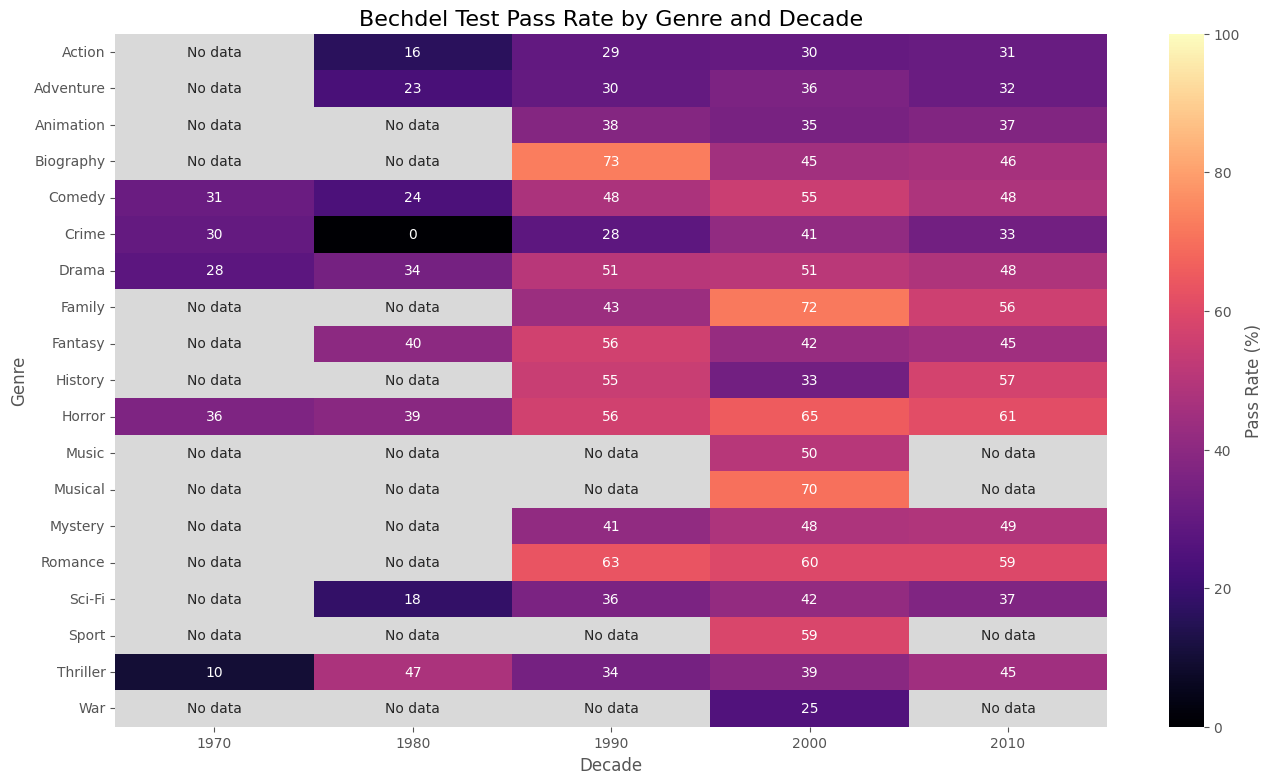

In [26]:
genre_df = movies_final.dropna(subset=['genres', 'binary']).copy()
genre_df = genre_df.assign(genres=genre_df['genres'].str.split(',')).explode('genres')
genre_df['decade'] = (genre_df['startYear'] // 10 * 10).astype(int)

genre_summary = (
    genre_df.groupby(['decade', 'genres'])['binary']
    .agg(
        films='size',
        pass_rate=lambda values: (values == 'PASS').mean() * 100
    )
    .reset_index()
 )
genre_summary = genre_summary[genre_summary['films'] >= 10]

pivot = genre_summary.pivot(index='genres', columns='decade', values='pass_rate')
pivot_display = pivot.fillna(-1)
annot_labels = pivot.apply(
    lambda column: column.map(lambda value: 'No data' if pd.isna(value) else f'{value:.0f}')
 )

heatmap_cmap = sns.color_palette('magma', as_cmap=True)
heatmap_cmap.set_under('#d9d9d9')

plt.figure(figsize=(16, 9))
bechdel_heatmap = sns.heatmap(
    pivot_display,
    annot=annot_labels,
    fmt='',
    cmap=heatmap_cmap,
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Pass Rate (%)'}
 )
bechdel_heatmap.collections[0].colorbar.ax.yaxis.set_major_formatter(percent_formatter)
plt.title('Bechdel Test Pass Rate by Genre and Decade', fontsize=16)
plt.xlabel('Decade')
plt.ylabel('Genre')
plt.show()

**D. Audience Perception Through Ratings**
IMDb ratings provide one measurable audience-perception signal. The line chart shows the long-term rating trend by lead group, and the distribution chart focuses on the latest decade only so the comparison is easier to read.

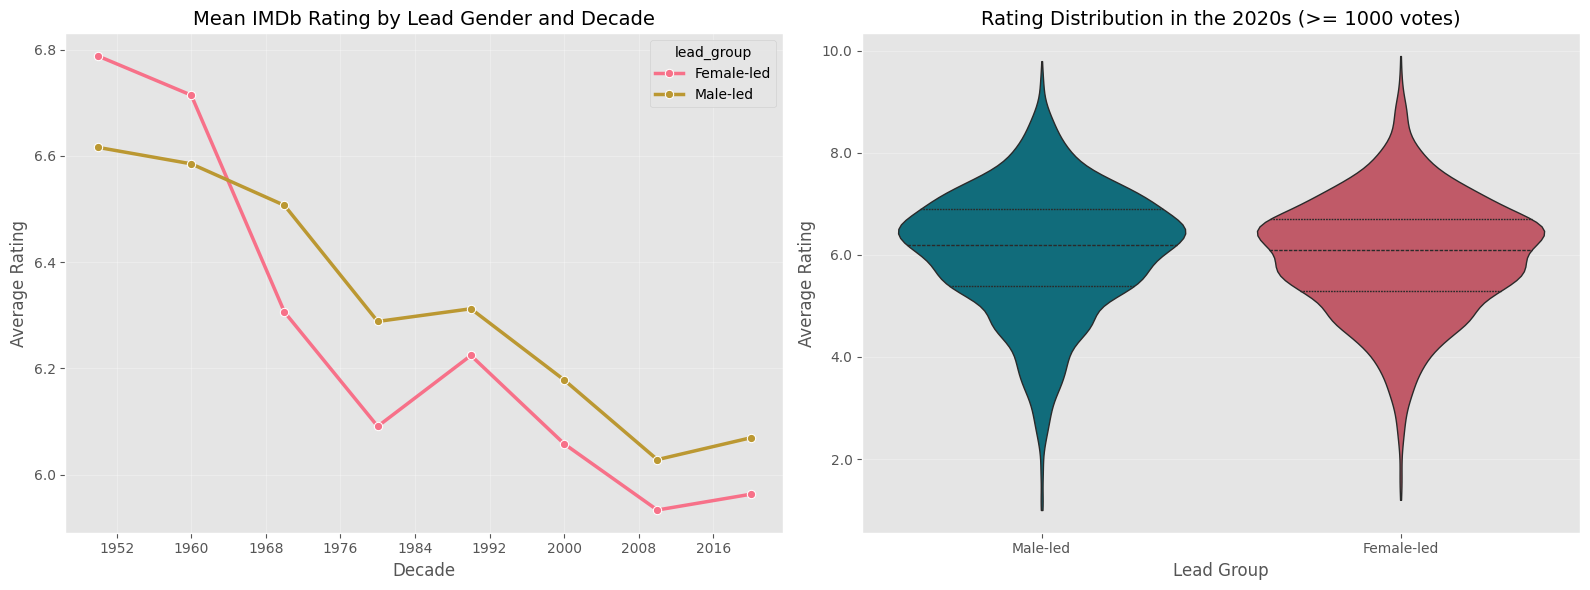

,decade,lead_group,mean_rating,median_rating,films,mean_votes
6,1980,Female-led,6.090805,6.2,783,12780.833972
7,1980,Male-led,6.288341,6.4,2513,26338.820533
8,1990,Female-led,6.224309,6.4,1049,21866.156339
9,1990,Male-led,6.312247,6.5,3217,44923.272614
10,2000,Female-led,6.058025,6.2,2299,28751.266638
11,2000,Male-led,6.178280,6.4,5732,45102.822575
12,2010,Female-led,5.933309,6.1,4134,23502.497339
13,2010,Male-led,6.028187,6.2,9004,34193.518214
14,2020,Female-led,5.962960,6.1,2932,15818.993520
15,2020,Male-led,6.069229,6.2,5047,18510.203487


In [27]:
rating_summary = (
    ratings_sample.groupby(['decade', 'lead_group'])
    .agg(
        mean_rating=('averageRating', 'mean'),
        median_rating=('averageRating', 'median'),
        films=('tconst', 'nunique'),
        mean_votes=('numVotes', 'mean')
    )
    .reset_index()
)

latest_decade = int(ratings_sample['decade'].dropna().max())

latest_rating_distribution = ratings_sample.loc[
    ratings_sample['decade'] == latest_decade
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=rating_summary,
    x='decade',
    y='mean_rating',
    hue='lead_group',
    marker='o',
    linewidth=2.5,
    ax=axes[0]
 )
axes[0].set_title('Mean IMDb Rating by Lead Gender and Decade', fontsize=14)
axes[0].set_ylabel('Average Rating')
axes[0].set_xlabel('Decade')
axes[0].grid(True, alpha=0.3)
style_decade_axis(axes[0])
axes[0].yaxis.set_major_formatter(rating_formatter)

sns.violinplot(
    data=latest_rating_distribution,
    x='lead_group',
    y='averageRating',
    hue='lead_group',
    inner='quart',
    cut=0,
    linewidth=1,
    palette={'Female-led': '#d1495b', 'Male-led': '#00798c'},
    ax=axes[1]
 )
if axes[1].legend_ is not None:
    axes[1].legend_.remove()
axes[1].set_title(f'Rating Distribution in the {latest_decade}s (>= {MIN_VOTES_FOR_RATINGS} votes)', fontsize=14)
axes[1].set_xlabel('Lead Group')
axes[1].set_ylabel('Average Rating')
axes[1].yaxis.set_major_formatter(rating_formatter)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

rating_summary.tail(10)

**D2. Latest-Decade Snapshot with Pie and Scatter Plots**
To make the ratings section easier to read, this block adds two simple visuals for the latest decade: a pie chart showing the split between female-led and male-led films, and a scatterplot showing how ratings and popularity relate to each other through vote counts.

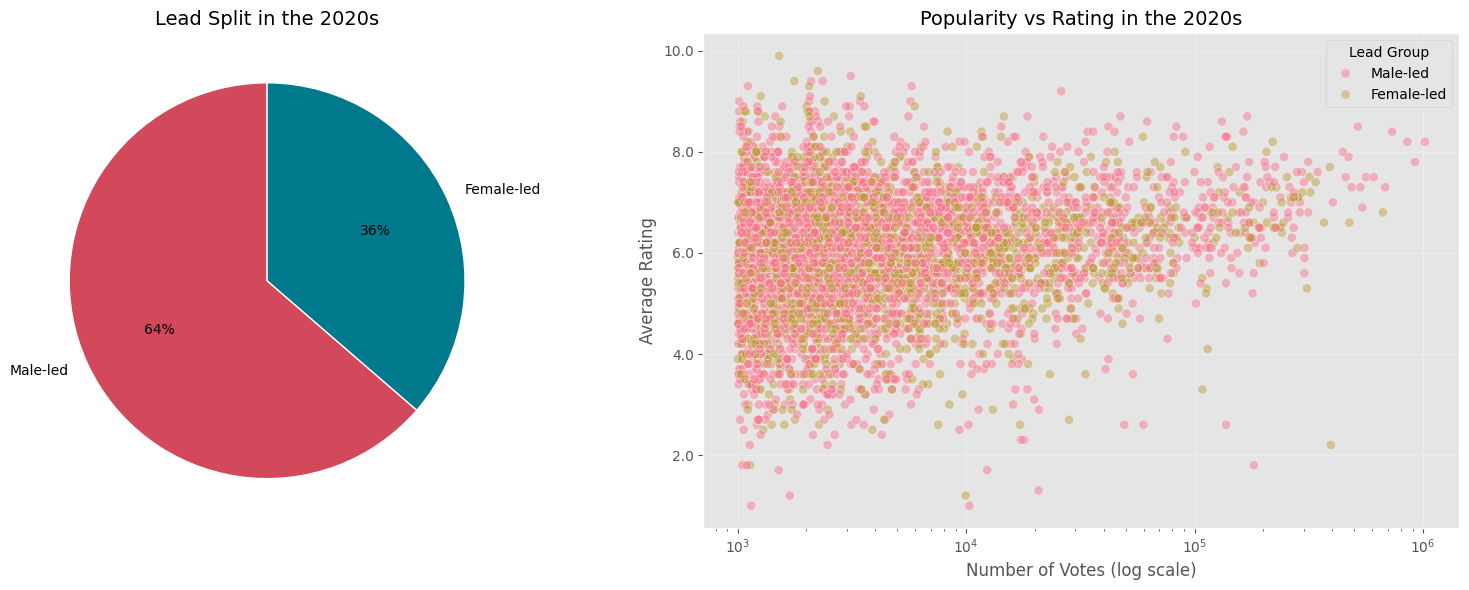

In [28]:
snapshot_decade = int(movies_final['decade'].max())
snapshot_lead_split = movies_final.loc[
    movies_final['decade'] == snapshot_decade,
    'lead_group'
].dropna().value_counts()

snapshot_scatter = ratings_sample.loc[ratings_sample['decade'] == snapshot_decade].copy()
snapshot_scatter = snapshot_scatter.sample(
    n=min(5000, len(snapshot_scatter)),
    random_state=42
 )

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].pie(
    snapshot_lead_split.values,
    labels=snapshot_lead_split.index,
    autopct='%1.0f%%',
    startangle=90,
    colors=['#d1495b', '#00798c'],
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
 )
axes[0].set_title(f'Lead Split in the {snapshot_decade}s', fontsize=14)

sns.scatterplot(
    data=snapshot_scatter,
    x='numVotes',
    y='averageRating',
    hue='lead_group',
    alpha=0.45,
    s=45,
    ax=axes[1]
 )
axes[1].set_xscale('log')
axes[1].set_title(f'Popularity vs Rating in the {snapshot_decade}s', fontsize=14)
axes[1].set_xlabel('Number of Votes (log scale)')
axes[1].set_ylabel('Average Rating')
axes[1].yaxis.set_major_formatter(rating_formatter)
axes[1].grid(True, alpha=0.3)
if axes[1].legend_ is not None:
    axes[1].legend_.set_title('Lead Group')

plt.tight_layout()
plt.show()

**F. Genre-Controlled Ratings Comparison**
A simple overall ratings gap can partly reflect genre composition rather than lead gender alone. This section recomputes the 2020s rating difference within genres that have enough female-led and male-led films, then summarizes the gap across those comparable genre slices.

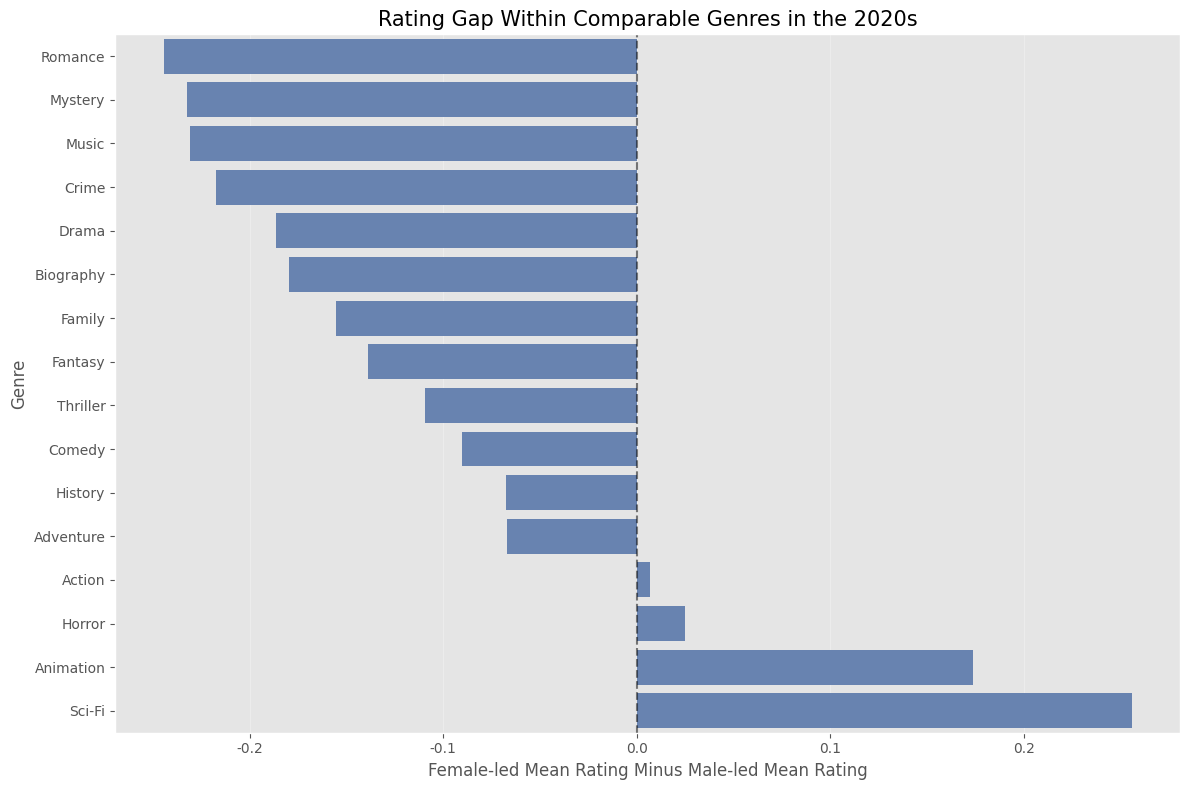

Weighted within-genre rating gap in the 2020s: -0.119 points across 16 genres with at least 50 films per lead group.


,genres,female_films,male_films,rating_gap
13,Romance,489.0,525.0,-0.245
12,Mystery,373.0,417.0,-0.233
11,Music,65.0,96.0,-0.231
5,Crime,333.0,843.0,-0.217
6,Drama,1674.0,2702.0,-0.187
3,Biography,123.0,289.0,-0.180
7,Family,132.0,197.0,-0.155
8,Fantasy,149.0,230.0,-0.139
15,Thriller,627.0,1138.0,-0.109
4,Comedy,908.0,1536.0,-0.090


In [30]:
latest_genre_ratings = ratings_sample.loc[ratings_sample['decade'] == latest_decade].copy()
latest_genre_ratings = latest_genre_ratings.dropna(subset=['genres']).copy()
latest_genre_ratings = latest_genre_ratings.assign(
    genres=latest_genre_ratings['genres'].str.split(',')
).explode('genres')

genre_rating_summary = (
    latest_genre_ratings.groupby(['genres', 'lead_group'])
    .agg(
        mean_rating=('averageRating', 'mean'),
        films=('tconst', 'nunique')
    )
    .reset_index()
 )

genre_counts = genre_rating_summary.pivot(index='genres', columns='lead_group', values='films').fillna(0)
eligible_genres = genre_counts[
    (genre_counts.get('Female-led', 0) >= 50) & (genre_counts.get('Male-led', 0) >= 50)
].index

genre_gap_table = (
    genre_rating_summary[genre_rating_summary['genres'].isin(eligible_genres)]
    .pivot(index='genres', columns='lead_group', values=['mean_rating', 'films'])
    .reset_index()
 )
genre_gap_table.columns = [
    'genres',
    'female_mean_rating',
    'male_mean_rating',
    'female_films',
    'male_films'
 ]
genre_gap_table['rating_gap'] = genre_gap_table['female_mean_rating'] - genre_gap_table['male_mean_rating']
genre_gap_table['comparison_weight'] = genre_gap_table[['female_films', 'male_films']].min(axis=1)
genre_gap_table = genre_gap_table.sort_values('rating_gap')

weighted_genre_gap = np.average(
    genre_gap_table['rating_gap'],
    weights=genre_gap_table['comparison_weight']
 )

plt.figure(figsize=(12, 8))
gap_ax = sns.barplot(
    data=genre_gap_table,
    x='rating_gap',
    y='genres',
    color='#5c80bc'
 )
gap_ax.axvline(0, color='black', linestyle='--', alpha=0.5)
gap_ax.set_title(f'Rating Gap Within Comparable Genres in the {latest_decade}s', fontsize=15)
gap_ax.set_xlabel('Female-led Mean Rating Minus Male-led Mean Rating')
gap_ax.set_ylabel('Genre')
gap_ax.xaxis.set_major_formatter(rating_formatter)
gap_ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f'Weighted within-genre rating gap in the {latest_decade}s: {weighted_genre_gap:.3f} points '
    f'across {len(genre_gap_table)} genres with at least 50 films per lead group.'
)

genre_gap_table[['genres', 'female_films', 'male_films', 'rating_gap']].round(3)

## 5. Key Findings and Reproducible Outputs
This section converts the main charts and the statistical checks into compact summary tables and saves the cleaned analysis tables to the processed-data folder. That makes the notebook easier to present and ensures the CSV outputs match the logic used in the notebook.

In [31]:
latest_lead_share = lead_share.sort_values('decade').tail(1).iloc[0]
latest_top_billed_share = top_billed_share.sort_values('decade').tail(1).iloc[0]
latest_ratings = rating_summary.sort_values(['decade', 'lead_group']).query('decade == decade.max()').copy()
latest_age_summary = (
    age_plot_df.groupby(['decade', 'category'])['age_at_release']
    .median()
    .reset_index(name='median_age')
    .query('decade == decade.max()')
 )

summary_table = pd.DataFrame(
    [
        {
            'metric': 'Female share of first-billed leads',
            'latest_decade': int(latest_lead_share['decade']),
            'value': round(latest_lead_share['female_lead_share'], 2)
        },
        {
            'metric': 'Female share of top-10 billed cast',
            'latest_decade': int(latest_top_billed_share['decade']),
            'value': round(latest_top_billed_share['female_top10_share'], 2)
        },
        {
            'metric': 'Weighted within-genre rating gap (female minus male)',
            'latest_decade': latest_decade,
            'value': round(weighted_genre_gap, 3)
        },
        {
            'metric': 'Bechdel-labeled films in matched subset',
            'latest_decade': ANALYSIS_START_YEAR,
            'value': int(movies_final['binary'].notna().sum())
        },
        {
            'metric': f'Ratings sample with at least {MIN_VOTES_FOR_RATINGS} votes',
            'latest_decade': ANALYSIS_START_YEAR,
            'value': int(len(ratings_sample))
        }
    ]
 )

movies_export = movies_final[[
    'tconst', 'primaryTitle', 'startYear', 'genres', 'averageRating', 'numVotes',
    'lead_category', 'lead_name', 'female_top10_share', 'binary', 'clean_test',
    'budget_2013$', 'domgross_2013$'
]].copy()

cast_export = cast_df[[
    'tconst', 'ordering', 'nconst', 'primaryName', 'category', 'characters',
    'birthYear', 'startYear', 'genres', 'age_at_release', 'decade'
]].copy()

if CACHE_READY:
    print('Processed files already exist. Skipping CSV export and reusing cached outputs.')
else:
    movies_export.to_csv(PROCESSED_MOVIES, index=False)
    cast_export.to_csv(PROCESSED_CAST, index=False)
    print('Saved refreshed analysis tables to ../data/processed/.')

display(summary_table)
display(stat_check)
display(genre_gap_table[['genres', 'female_films', 'male_films', 'rating_gap']].round(3))
display(latest_age_summary)
display(latest_ratings)

Processed files already exist. Skipping CSV export and reusing cached outputs.


,metric,latest_decade,value
0,Female share of first-billed leads,2020,36.350
1,Female share of top-10 billed cast,2020,37.300
2,Weighted within-genre rating gap (female minus...,2020,-0.119
3,Bechdel-labeled films in matched subset,1950,1784.000
4,Ratings sample with at least 1000 votes,1950,42802.000


,comparison,decade,observed_gap,ci_lower,ci_upper,female_n,male_n
0,Mean IMDb rating: female-led minus male-led,2020,-0.106,-0.159,-0.052,2932,5047
1,Median age: actresses minus actors,2020,-8.000,-9.000,-7.000,64492,108389


,genres,female_films,male_films,rating_gap
13,Romance,489.0,525.0,-0.245
12,Mystery,373.0,417.0,-0.233
11,Music,65.0,96.0,-0.231
5,Crime,333.0,843.0,-0.217
6,Drama,1674.0,2702.0,-0.187
3,Biography,123.0,289.0,-0.180
7,Family,132.0,197.0,-0.155
8,Fantasy,149.0,230.0,-0.139
15,Thriller,627.0,1138.0,-0.109
4,Comedy,908.0,1536.0,-0.090


,decade,category,median_age
14,2020,actor,47.0
15,2020,actress,39.0


,decade,lead_group,mean_rating,median_rating,films,mean_votes
14,2020,Female-led,5.962960,6.1,2932,15818.993520
15,2020,Male-led,6.069229,6.2,5047,18510.203487


## 7. Conclusion and Limitations
- **Lead roles vs. screen presence:** The notebook separates first-billed lead roles from the broader top-10 billed cast, so it tracks both female-led films and women's share of prominent on-screen presence over time.

- **Genre variation:** Progress is not uniform across the industry. The genre-by-decade lead table shows that some genres gained female-led representation much faster than others, so any single overall trend hides important structural differences.

- **Age patterns:** The age plot measures the age distribution of prominent credited performers, not total career length. In the 2020s sample, actresses are still cast younger than actors, and the bootstrap interval suggests that this is a stable gap rather than a visual artifact.

- **Audience perception:** IMDb ratings and vote counts provide a measurable audience response signal for female-led versus male-led films. The overall ratings gap is small, and the genre-controlled comparison helps show how much of that gap remains after partially accounting for genre mix.

- **Bechdel scope:** The Bechdel analysis is based on the matched external subset only, so it should be interpreted as a labeled sample rather than complete coverage of the IMDb movie universe.

- **Reproducibility:** The notebook writes refreshed movie-level and cast-level analysis tables to the processed-data folder so the exported CSVs stay aligned with the notebook logic.
